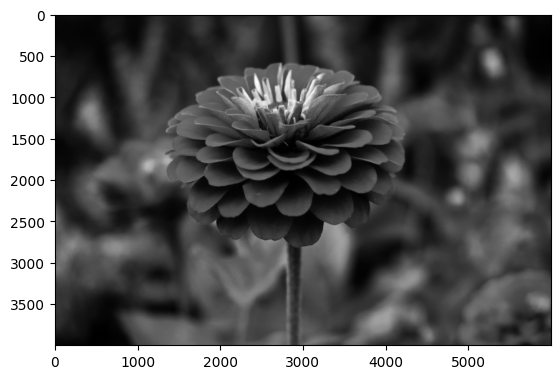

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

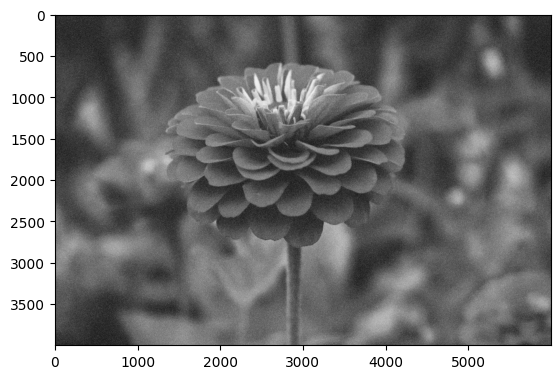

In [2]:
#task1 Gaussian
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

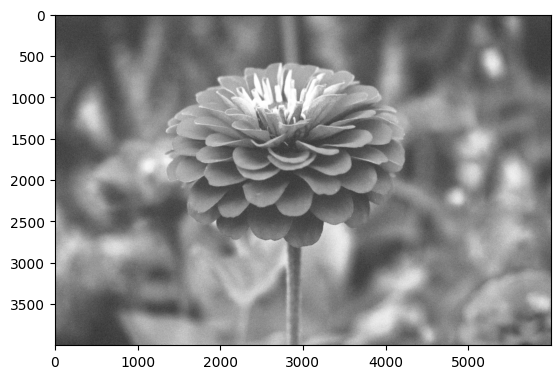

In [3]:
#task1 Constant
a = 50
b = 150
noise_constant = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_constant, a, b)
image_noise_constant = cv2.add(image_gray, noise_constant)
plt.imshow(image_noise_constant, cmap='gray')

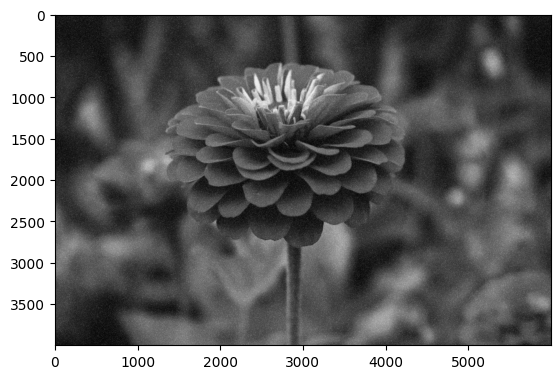

In [4]:
#task2 Median 1 Gauss
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
plt.imshow(image_gauss_median, cmap="gray")

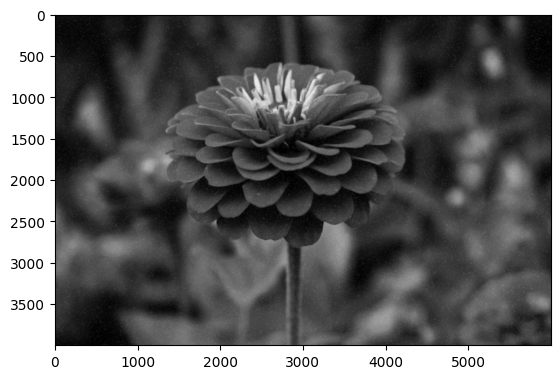

In [5]:
#task2 Median 2 Gauss
image_gauss_median_2 = cv2.medianBlur(image_noise_gauss, 13)
plt.imshow(image_gauss_median_2, cmap="gray")

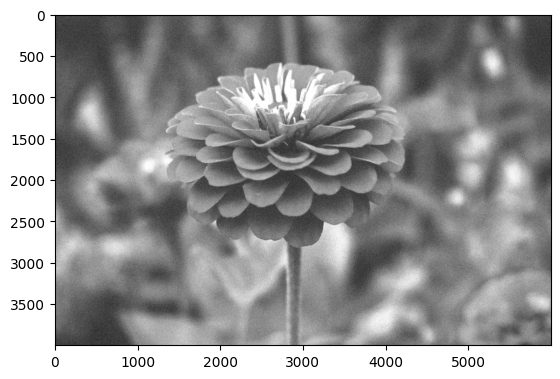

In [6]:
#task2 Median 1 Constant
image_constant_median = cv2.medianBlur(image_noise_constant, 3)
plt.imshow(image_constant_median, cmap="gray")

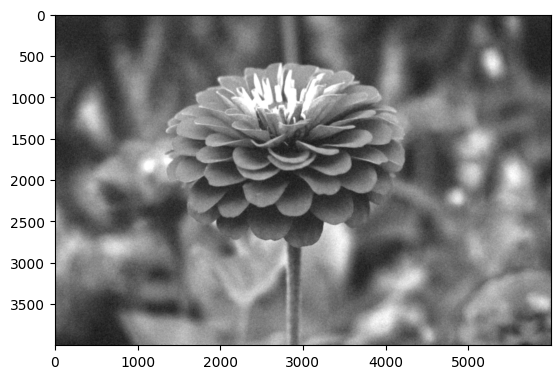

In [7]:
#task2 Median 2 Constant
image_constant_median_2 = cv2.medianBlur(image_noise_constant, 13)
plt.imshow(image_constant_median_2, cmap="gray")

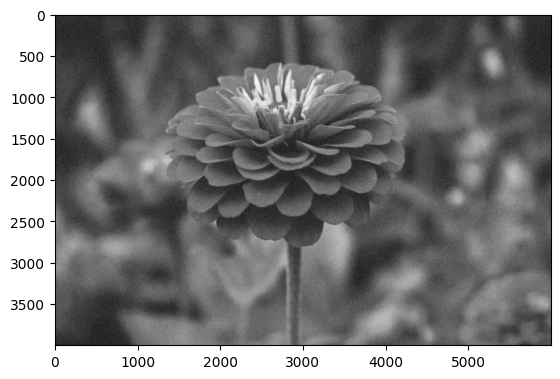

In [15]:
#task2 Gaussian 1 Gauss
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)
plt.imshow(image_gauss_gauss, cmap='gray')

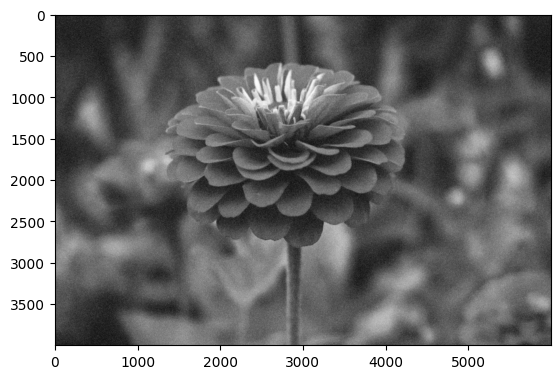

In [16]:
#task2 Gaussian 2 Gauss
image_gauss_gauss_2 = cv2.GaussianBlur(image_noise_gauss,(11,11),0)
plt.imshow(image_gauss_gauss_2, cmap='gray')

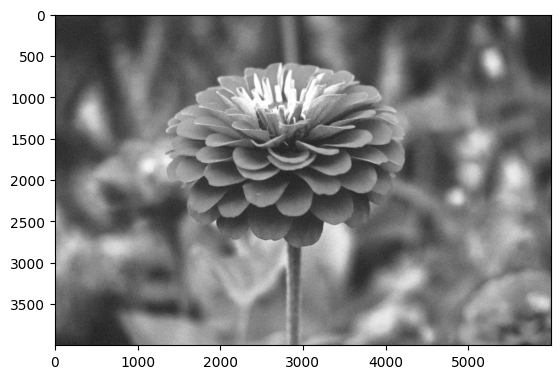

In [8]:
#task2 Gaussian 1 Constant
image_constant_gauss = cv2.GaussianBlur(image_noise_constant,(5,5),0)
plt.imshow(image_constant_gauss, cmap='gray')

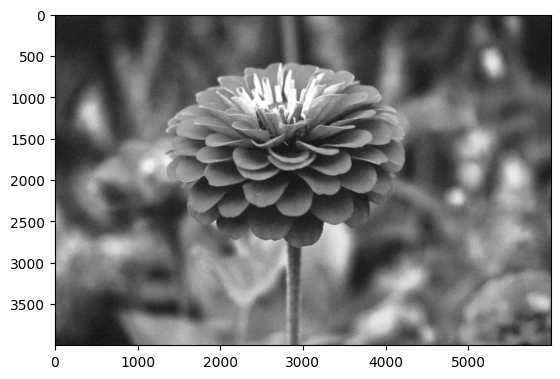

In [9]:
#task2 Gaussian 2 Constant
image_constant_gauss_2 = cv2.GaussianBlur(image_noise_constant,(11,11),0)
plt.imshow(image_constant_gauss_2, cmap='gray')

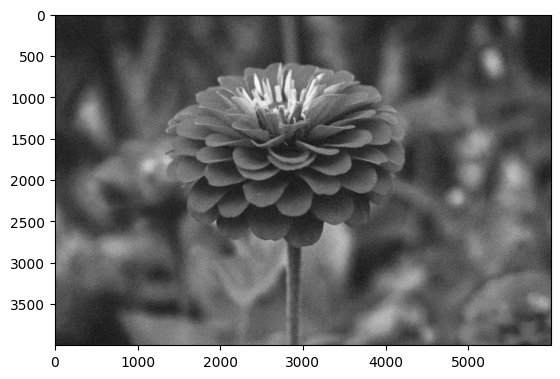

In [17]:
#task2 Bil 1 Gauss
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)
plt.imshow(image_gauss_bilat, cmap='gray')

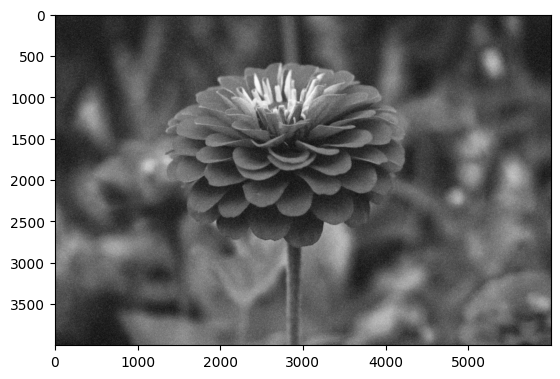

In [18]:
#task2 Bil 2 Gauss
image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss,11,80,25)
plt.imshow(image_gauss_bilat_2, cmap='gray')

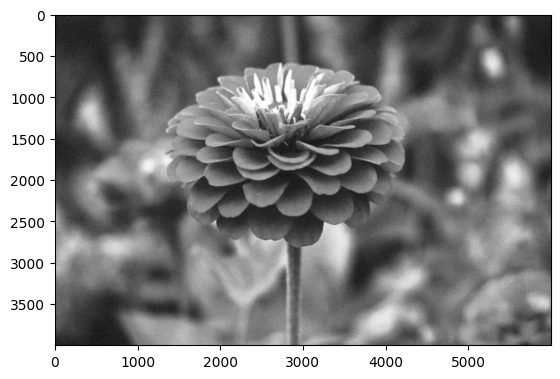

In [10]:
#task2 Bil 1 Constant
image_constant_bilat = cv2.bilateralFilter(image_noise_constant,9,75,75)
plt.imshow(image_constant_bilat, cmap='gray')

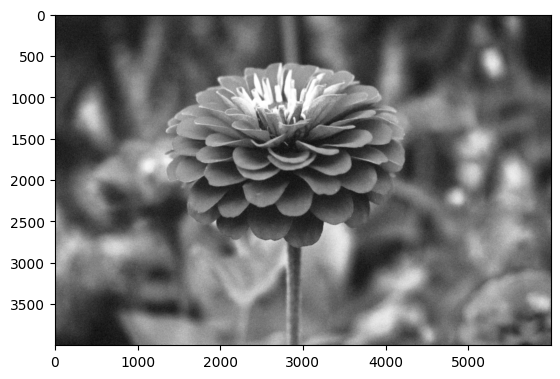

In [11]:
#task2 Bil 2 Constant
image_constant_bilat_2 = cv2.bilateralFilter(image_noise_constant,11,80,25)
plt.imshow(image_constant_bilat_2, cmap='gray')

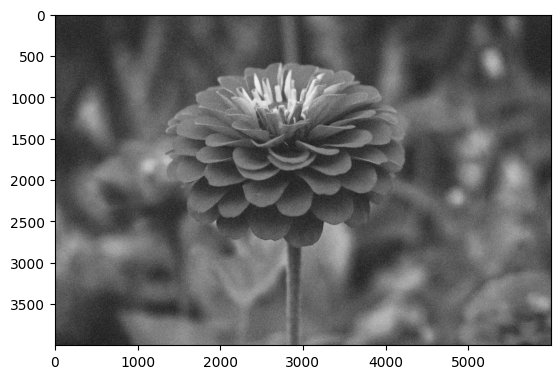

In [19]:
#task2 NL 1
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
plt.imshow(image_gauss_nlm, cmap='gray')

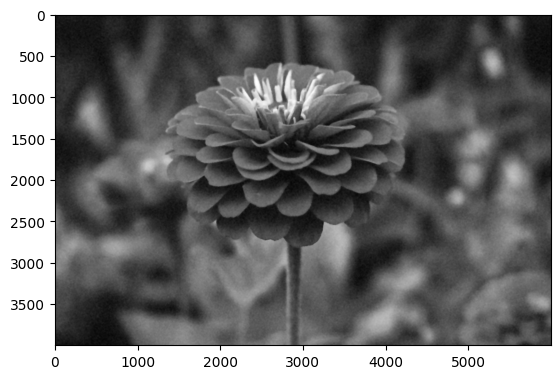

In [20]:
#task2 NL 2
image_gauss_nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 50)
plt.imshow(image_gauss_nlm_2, cmap='gray')

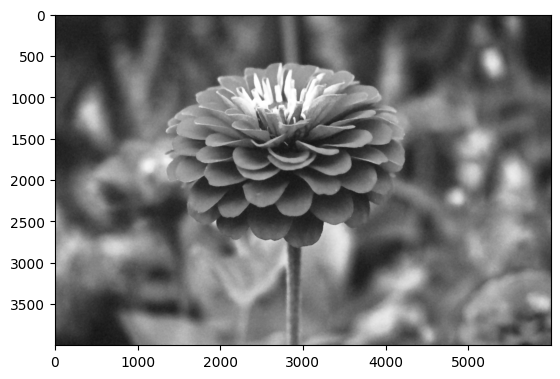

In [12]:
#task2 NL 1 Constant
image_constant_nlm = cv2.fastNlMeansDenoising(image_noise_constant, h = 20)
plt.imshow(image_constant_nlm, cmap='gray')

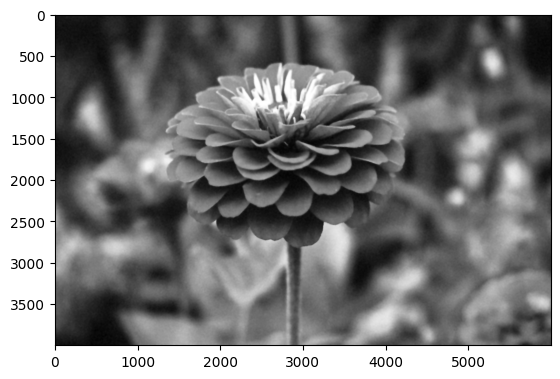

In [13]:
#task2 NL 2 Constant
image_constant_nlm_2 = cv2.fastNlMeansDenoising(image_noise_constant, h = 50)
plt.imshow(image_constant_nlm_2, cmap='gray')

In [24]:
#task3
from skimage.metrics import structural_similarity, mean_squared_error
mse = []
ssim = []
images = [image_gauss_median, image_gauss_median_2, image_gauss_gauss, image_gauss_gauss_2, image_gauss_bilat, image_gauss_bilat_2, image_gauss_nlm, image_gauss_nlm_2]
names = ['Median 1', 'Median 2', 'Gaussian 1', 'Gaussian 2', 'Bil 1', 'Bil 2', 'NL 1', 'NL 2']
for img in images:
    m = mean_squared_error(image_gray, img)
    (s, diff) = structural_similarity(image_gray, img, full=True)
    mse.append(m)
    ssim.append(s)


best_mse = names[mse.index(min(mse))]
best_ssim = names[ssim.index(max(ssim))]
print('Gauss: ')
print('best mse:', best_mse)
print('best ssim:', best_ssim)

mse = []
ssim = []
images = [image_constant_median, image_constant_median_2, image_constant_gauss, image_constant_gauss_2, image_constant_bilat, image_constant_bilat_2, image_constant_nlm, image_constant_nlm_2]
names = ['Median 1', 'Median 2', 'Gaussian 1', 'Gaussian 2', 'Bil 1', 'Bil 2', 'NL 1', 'NL 2']
for img in images:
    m = mean_squared_error(image_gray, img)
    (s, diff) = structural_similarity(image_gray, img, full=True)
    mse.append(m)
    ssim.append(s)


best_mse = names[mse.index(min(mse))]
best_ssim = names[ssim.index(max(ssim))]
print('Constant: ')
print('best mse:', best_mse)
print('best ssim:', best_ssim)

Gauss: 
best mse: Median 2
best ssim: Median 2
Constant: 
best mse: NL 2
best ssim: NL 2
